In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# downloading data
data = "https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv"
!wget $data

--2026-05-26 10:22:45--  https://raw.githubusercontent.com/gastonstat/CreditScoring/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv.6’

CreditScoring.csv.6 100%[===================>] 178.21K  --.-KB/s    in 0.05s   

2026-05-26 10:22:47 (3.85 MB/s) - ‘CreditScoring.csv.6’ saved [182489/182489]



In [3]:
df = pd.read_csv('CreditScoring.csv')

In [4]:
df.head()

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910


In [5]:
#standardise column names 
df.columns = df.columns.str.lower()

In [6]:
df.dtypes

status       int64
seniority    int64
home         int64
time         int64
age          int64
marital      int64
records      int64
job          int64
expenses     int64
income       int64
assets       int64
debt         int64
amount       int64
price        int64
dtype: object

In [7]:
# decoding categorical variables from R 
df.status = df.status.map({1: 'ok', 2: 'default', 0: 'unknown'})

df.home = df.home.map({
    1: 'rent', 
    2: 'owner',
    3: 'priv',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unknown'})

df.marital = df.marital.map({
    1: 'single', 
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unknown'
})

df.records = df.records.map({
    1: 'no_rec', 
    2: 'yes_rec'})

df.job = df.job.map({
    1: 'fixed', 
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unknown'})


In [8]:
df[['marital', 'home', 'status', 'records', 'job']] = df[['marital', 'home', 'status', 'records', 'job']].astype('str')

In [9]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no_rec,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no_rec,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes_rec,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no_rec,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no_rec,fixed,46,107,0,0,310,910


In [10]:
#Get statistical summary of the numerical columns
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [11]:
numericals = list(df.dtypes[df.dtypes == 'int'].index)

In [12]:
#replace columns with null values with actual numpy nan
for col in numericals:
    df[col] = df[col].replace(99999999.0, np.nan)

In [13]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no_rec,freelance,73,129.0,0.0,0.0,800,846
1,ok,17,rent,60,58,widow,no_rec,fixed,48,131.0,0.0,0.0,1000,1658
2,default,10,owner,36,46,married,yes_rec,freelance,90,200.0,3000.0,0.0,2000,2985
3,ok,0,rent,60,24,single,no_rec,fixed,63,182.0,2500.0,0.0,900,1325
4,ok,0,rent,36,26,single,no_rec,fixed,46,107.0,0.0,0.0,310,910


In [14]:
df.isnull().sum()

status        0
seniority     0
home          0
time          0
age           0
marital       0
records       0
job           0
expenses      0
income       34
assets       47
debt         18
amount        0
price         0
dtype: int64

In [15]:
# fill null values with median
df[['income', 'assets', 'debt']] = df[['income', 'assets', 'debt']].fillna(df[['income', 'assets', 'debt']].median())

In [16]:
df.describe()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000,4455.000000
mean,7.987205,46.441751,37.077666,55.568799,130.487542,5378.077890,341.562963,1039.021773,1462.875645
std,8.173444,14.655225,10.984856,19.515878,86.042072,11514.557029,1243.532086,474.543007,628.089913
min,0.000000,6.000000,18.000000,35.000000,0.000000,0.000000,0.000000,100.000000,105.000000
25%,2.000000,36.000000,28.000000,35.000000,80.000000,0.000000,0.000000,700.000000,1117.500000
50%,5.000000,48.000000,36.000000,51.000000,120.000000,3000.000000,0.000000,1000.000000,1400.000000
75%,12.000000,60.000000,45.000000,72.000000,164.000000,6000.000000,0.000000,1300.000000,1692.000000
max,48.000000,72.000000,68.000000,180.000000,959.000000,300000.000000,30000.000000,5000.000000,11140.000000


In [17]:
#convert the target variable into binary 

df['status'] = (df['status'] == 'default').astype('int')

In [18]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,0,9,rent,60,30,married,no_rec,freelance,73,129.0,0.0,0.0,800,846
1,0,17,rent,60,58,widow,no_rec,fixed,48,131.0,0.0,0.0,1000,1658
2,1,10,owner,36,46,married,yes_rec,freelance,90,200.0,3000.0,0.0,2000,2985
3,0,0,rent,60,24,single,no_rec,fixed,63,182.0,2500.0,0.0,900,1325
4,0,0,rent,36,26,single,no_rec,fixed,46,107.0,0.0,0.0,310,910


In [19]:
#Study the status column
global_default = df['status'].mean()
global_default

np.float64(0.2814814814814815)

In [20]:
numericals

['seniority',
 'time',
 'age',
 'expenses',
 'income',
 'assets',
 'debt',
 'amount',
 'price']

In [21]:
categoricals = list(df.dtypes[df.dtypes == 'str'].index)

In [22]:
categoricals

['home', 'marital', 'records', 'job']

# Exploratory data analysis: EDA

In [23]:
df['status'].value_counts()

status
0    3201
1    1254
Name: count, dtype: int64

# Decision trees 
- finding the best split for one column
- finding the best split for the entire data set
- Decision tree learning algorithym

In [29]:
#Train, test and validation data sets
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size = 0.20, random_state=21)
df_train, df_val = train_test_split(df_full_train, test_size = 0.25, random_state=21)


In [32]:
#resetting index
df_train = df_train.reset_index(drop=True)
df_full_train = df_full_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [35]:
y_train = df_train['status'].values
y_test = df_test['status'].values
y_val = df_val['status'].values

In [36]:
# Remove the target column from the main data frames
del df_train['status']
del df_full_train['status']
del df_test['status']
del df_val['status']

In [52]:
from sklearn.tree import DecisionTreeClassifier # for decision tree
from sklearn.feature_extraction import DictVectorizer #for feature matrix
from sklearn.metrics import roc_auc_score

In [47]:
train_dicts = df_train.to_dict(orient='records')
val_dicts = df_val.to_dict(orient='records')
test_dicts = df_test.to_dict(orient='records')

In [48]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_val = dv.transform(val_dicts)
X_test = dv.transform(test_dicts)

In [45]:
#training the decision tree algorithym
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [54]:
#validating the model
y_pred = dt.predict_proba(X_val)[:, 1]

In [55]:
roc_auc_score(y_val, y_pred)

0.6584206997439961

In [58]:
y_pred_t = dt.predict_proba(X_train)[:, 1]

In [60]:
roc_auc_score(y_pred_t, y_train)

1.0

In [64]:
Xi = df_train.iloc[0].to_dict()
Xi

{'seniority': 1,
 'home': 'other',
 'time': 48,
 'age': 23,
 'marital': 'single',
 'records': 'no_rec',
 'job': 'partime',
 'expenses': 35,
 'income': 147.0,
 'assets': 0.0,
 'debt': 0.0,
 'amount': 1000,
 'price': 1843}

In [66]:
#Re training the tree with max-depth limit
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [68]:
y_pred = dt.predict_proba(X_train)[:,1]
auc = roc_auc_score(y_train, y_pred)
print('train:', auc)

y_pred = dt.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred)
print('val:', auc)

train: 0.7589066961083527
val: 0.7865872241862735


# Parameter Tuning for Decision trees
- selecting max_depth
- selecting min_sample_leaf

In [78]:
d = [1,2,3,4,5,6,7,8,9,10]

for i in d:
    
    dt = DecisionTreeClassifier(max_depth=i)
    dt.fit(X_train, y_train)
    y_pred = dt.predict_proba(X_val)[:,1]
    auc = roc_auc_score(y_val, y_pred)
    print('%4s -> %.3f' % (i, auc))

   1 -> 0.654
   2 -> 0.735
   3 -> 0.787
   4 -> 0.785
   5 -> 0.768
   6 -> 0.756
   7 -> 0.740
   8 -> 0.714
   9 -> 0.678
  10 -> 0.674


In [83]:
#evaluating the auc for different max-depth and min-samples-leaf
scores = []
for d in [3, 4, 5, 6]:
    for s in [1, 2, 3, 5, 10, 20, 100, 200, 500]:
        dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
        dt.fit(X_train, y_train)
        
        y_pred = dt.predict_proba(X_val)[:,1]
        auc = roc_auc_score(y_val, y_pred)
        scores.append((d, s,  auc))

In [89]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc']) #creating a data frame

In [92]:
df_scores = df_scores.sort_values('auc', ascending=False)
df_scores.head()

,max_depth,min_samples_leaf,auc
33,6,100,0.802865
24,5,100,0.800091
32,6,20,0.795310
31,6,10,0.794386
14,4,20,0.790894


In [95]:
# create a pivot data frame to visualise the scores better
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])

In [96]:
df_scores_pivot

auc                              
max_depth                3         4         5         6
min_samples_leaf                                        
1                 0.786587  0.784917  0.766960  0.757287
2                 0.786587  0.784917  0.768316  0.767280
3                 0.786587  0.784917  0.775180  0.766735
5                 0.786587  0.784917  0.780504  0.778474
10                0.786587  0.784786  0.788821  0.794386
20                0.786587  0.790894  0.789681  0.795310
100               0.786252  0.788934  0.800091  0.802865
200               0.753743  0.755452  0.757235  0.757765
500               0.693758  0.693758  0.693758  0.693758

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

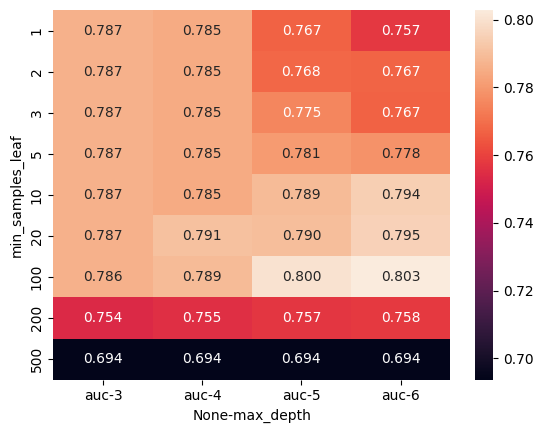

In [99]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

In [105]:
#final Decision tree model
dt = DecisionTreeClassifier(max_depth=6, min_samples_leaf=100)
dt.fit(X_train, y_train)


0.8028648055589419

# Ensembles and random forest
- Board of experts
- Esembling models
- Random forest - ensemble decision trees
- Tuning random forest
